# Intra-Patient vs Inter-Patient Evaluation

This notebook evaluates all trained models on both **inter-patient** and **intra-patient** test splits,
then produces side-by-side bar plots to compare generalisation performance.

| Split | Description |
|-------|-------------|
| **Inter-patient** | Test subjects that were *never seen* during training (different patients). Measures how well the model generalises to entirely new individuals. |
| **Intra-patient** | Second temporal half of the *training* subjects. Measures how well the model captures temporal dynamics of known individuals. |

A model that scores well on both splits demonstrates strong generalisation across patients *and* time.

In [1]:
import os
import sys
from pathlib import Path

# Ensure project root is on path
notebook_dir = Path().absolute()
if notebook_dir.name == "examples":
    os.chdir(notebook_dir.parent)

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])
%matplotlib inline

## 1. Configuration

Choose the dataset and whether to recompute metrics from checkpoints or load precomputed metrics from `results/`.

In [2]:
# -- Configuration ------------------------------------------------------------
DATASET_ORDER = ["ts_young", "lsd"]
DATASET_CONFIGS = {
    "ts_young": {
        "label": "TS Young",
        "data_path": "data/ts_young/ts_young_TR0.72.mat",
        "lsd_data_dir": "data/lsd",
    },
    "lsd": {
        "label": "LSD",
        "data_path": "data/ts_young/ts_young_TR0.72.mat",
        "lsd_data_dir": "data/lsd",
    },
}
CHECKPOINT_DIR = "checkpoints"
RESULTS_DIR = "results"
USE_PRECOMPUTED_RESULTS = True
RESULT_FILES_BY_DATASET = {
    "ts_young": None,  # e.g. ["results/ts_young_hopf.json"]
    "lsd": None,       # e.g. ["results/lsd_hopf.json"]
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DISPLAY_METRICS = [
    "fc_correlation",
    "fc_mse",
    "fcd_ks",
    "phfcd_ks",
    "metastability_diff",
    "power_spectrum_distance",
    "temporal_correlation",
    "autocorr_distance",
    "phase_fc_correlation",
]

METRIC_LABELS = {
    "fc_correlation": "FC Correlation ↑",
    "fc_mse": "FC MSE ↓",
    "fcd_ks": "FCD (KS) ↓",
    "phfcd_ks": "Phase-FCD (KS) ↓",
    "metastability_diff": "Metastability Diff ↓",
    "power_spectrum_distance": "Power Spectrum Dist ↓",
    "temporal_correlation": "Temporal Correlation ↑",
    "autocorr_distance": "Autocorr Distance ↓",
    "phase_fc_correlation": "Phase FC Correlation ↑",
}

HIGHER_IS_BETTER = {"fc_correlation", "temporal_correlation", "phase_fc_correlation"}
DATASET_LABELS = {key: cfg["label"] for key, cfg in DATASET_CONFIGS.items()}

print(f"Device: {DEVICE}")
print(f"Datasets: {[DATASET_LABELS[d] for d in DATASET_ORDER]}")
print(
    "Using precomputed results from results/"
    if USE_PRECOMPUTED_RESULTS
    else "Recomputing metrics from checkpoints"
)


Device: cpu
Datasets: ['TS Young', 'LSD']
Using precomputed results from results/


## 2. Load Dataset & Create Data Loaders

We only need the dataset and loaders when recomputing metrics. If `USE_PRECOMPUTED_RESULTS = True`, this step is skipped.

In [3]:
from src.dataset import load_dataset, create_data_loaders
from src.training import HopfConfig

dataset_contexts = {}

for dataset_type in DATASET_ORDER:
    cfg = HopfConfig()
    cfg.dataset_type = dataset_type
    cfg.data_path = DATASET_CONFIGS[dataset_type]["data_path"]
    cfg.lsd_data_dir = DATASET_CONFIGS[dataset_type]["lsd_data_dir"]
    cfg.use_wandb = False
    cfg.dt_min = 0.05

    context = {
        "cfg": cfg,
        "dataset": None,
        "window_size": None,
        "test_inter_loader": None,
        "test_intra_loader": None,
    }

    if USE_PRECOMPUTED_RESULTS:
        print(f"[{DATASET_LABELS[dataset_type]}] Skipping dataset/loading step because USE_PRECOMPUTED_RESULTS=True")
    else:
        dataset = load_dataset(cfg, DEVICE)
        window_size = min(100, dataset.n_timepoints // 2)
        _, _, test_inter_loader, test_intra_loader = create_data_loaders(
            dataset=dataset,
            window_size=window_size,
            batch_size=cfg.batch_size,
            n_windows_per_epoch=cfg.n_windows_per_epoch,
            train_ratio=cfg.train_ratio,
            val_ratio=cfg.val_ratio,
            seed=cfg.seed,
            device=DEVICE,
        )
        context.update(
            dataset=dataset,
            window_size=window_size,
            test_inter_loader=test_inter_loader,
            test_intra_loader=test_intra_loader,
        )
        print(f"[{DATASET_LABELS[dataset_type]}] n_rois       : {dataset.n_rois}")
        print(f"[{DATASET_LABELS[dataset_type]}] n_subjects   : {dataset.timeseries.shape[0]}")
        print(f"[{DATASET_LABELS[dataset_type]}] n_timepoints : {dataset.n_timepoints}")
        print(f"[{DATASET_LABELS[dataset_type]}] window_size  : {window_size}")
        print(f"[{DATASET_LABELS[dataset_type]}] test_inter batches : {len(test_inter_loader)}")
        print(f"[{DATASET_LABELS[dataset_type]}] test_intra batches : {len(test_intra_loader)}")

    dataset_contexts[dataset_type] = context


[TS Young] Skipping dataset/loading step because USE_PRECOMPUTED_RESULTS=True
[LSD] Skipping dataset/loading step because USE_PRECOMPUTED_RESULTS=True


## 3. Discover Inputs

Either auto-discover checkpoints for recomputation or collect matching precomputed JSON files from `results/`.

In [4]:
import json

from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ("gnn_hopf", "GNN Hopf"),
    ("hybrid_neural", "Hybrid+Neural"),
    ("hybrid_hopf", "Hybrid Hopf"),
    ("nsde", "Neural SDE"),
    ("hopf", "Hopf"),
]

def _short_label(stem: str) -> str:
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (" (Grid)" if "grid" in lower else "")
    return stem

results_by_dataset = {}

for dataset_type in DATASET_ORDER:
    context = dataset_contexts[dataset_type]
    models = {}
    result_paths = []

    if USE_PRECOMPUTED_RESULTS:
        configured_paths = RESULT_FILES_BY_DATASET.get(dataset_type)
        if configured_paths is not None:
            result_paths = [Path(p) for p in configured_paths]
        else:
            result_paths = sorted(Path(RESULTS_DIR).glob(f"{dataset_type}_*.json"))
            result_paths = [
                p for p in result_paths
                if p.stem != f"{dataset_type}_intra_vs_inter_results"
            ]

        print(f"[{DATASET_LABELS[dataset_type]}] Found {len(result_paths)} precomputed result files:")
        for p in result_paths:
            print(f"  {p}")
    else:
        ckpt_dir = Path(CHECKPOINT_DIR)
        checkpoint_paths = sorted(ckpt_dir.glob(f"*{dataset_type}*.pt"))
        print(f"[{DATASET_LABELS[dataset_type]}] Found {len(checkpoint_paths)} checkpoints:")
        for p in checkpoint_paths:
            print(f"  {p}")

        dataset = context["dataset"]
        for ckpt_path in checkpoint_paths:
            try:
                model, mtype, _ = load_model_from_checkpoint(str(ckpt_path), device=DEVICE)
                if model.n_rois != dataset.n_rois:
                    print(f"  Skipping {ckpt_path.name}: ROI mismatch ({model.n_rois} != {dataset.n_rois})")
                    continue
                label = _short_label(ckpt_path.stem)
                models[label] = model
                print(f"  Loaded '{label}' ({mtype})")
            except Exception as exc:
                print(f"  Failed to load {ckpt_path.name}: {exc}")

    results_by_dataset[dataset_type] = {
        "models": models,
        "result_paths": result_paths,
    }


[TS Young] Found 0 precomputed result files:
[LSD] Found 2 precomputed result files:
  results/lsd_control_metrics.json
  results/lsd_paper_metrics.json


## 4. Evaluate Models on Both Test Splits

For each model we run `evaluate_model_loader_metrics` on both the inter-patient and intra-patient loaders, collecting the mean and standard deviation of every metric across batches.

In [5]:
from src.utils.evaluation import evaluate_model_loader_metrics, format_metrics_mean_std

for dataset_type in DATASET_ORDER:
    context = dataset_contexts[dataset_type]
    dataset_results = results_by_dataset[dataset_type]

    inter_results = {}
    intra_results = {}

    if USE_PRECOMPUTED_RESULTS:
        for result_path in dataset_results["result_paths"]:
            with open(result_path, "r") as f:
                payload = json.load(f)

            if payload.get("dataset_type") != dataset_type:
                print(f"[{DATASET_LABELS[dataset_type]}] Skipping {result_path.name}: dataset mismatch ({payload.get('dataset_type')})")
                continue

            metrics = payload.get("metrics", {})
            if "test_inter" not in metrics or "test_intra" not in metrics:
                print(f"[{DATASET_LABELS[dataset_type]}] Skipping {result_path.name}: missing test_inter/test_intra metrics")
                continue

            name = _short_label(payload.get("model", result_path.stem))
            inter_results[name] = {k: float(v) for k, v in metrics["test_inter"].items()}
            intra_results[name] = {k: float(v) for k, v in metrics["test_intra"].items()}

        dataset_results["models"] = {name: None for name in inter_results}
        print(f"[{DATASET_LABELS[dataset_type]}] Loaded precomputed metrics for {len(inter_results)} model(s): {list(inter_results.keys())}")
    else:
        cfg = context["cfg"]
        for name, model in dataset_results["models"].items():
            print(f"[{DATASET_LABELS[dataset_type]}] Evaluating {name} ...")
            inter_results[name] = evaluate_model_loader_metrics(
                model, context["test_inter_loader"], cfg, n_steps=context["window_size"], return_std=True,
            )
            intra_results[name] = evaluate_model_loader_metrics(
                model, context["test_intra_loader"], cfg, n_steps=context["window_size"], return_std=True,
            )
            print(f"  Inter: {format_metrics_mean_std(inter_results[name])}")
            print(f"  Intra: {format_metrics_mean_std(intra_results[name])}")
            print()

    dataset_results["inter_results"] = inter_results
    dataset_results["intra_results"] = intra_results
    dataset_results["model_names"] = list(inter_results.keys())

print("Metrics ready for all datasets.")


[TS Young] Loaded precomputed metrics for 0 model(s): []
[LSD] Skipping lsd_control_metrics.json: dataset mismatch (None)
[LSD] Skipping lsd_paper_metrics.json: dataset mismatch (None)
[LSD] Loaded precomputed metrics for 0 model(s): []
Metrics ready for all datasets.


## 5. Summary Table

Quick numerical overview before plotting.

In [6]:
import pandas as pd

rows = []
for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    for name in dataset_results["model_names"]:
        for split_name, results in [("Inter", dataset_results["inter_results"]), ("Intra", dataset_results["intra_results"])]:
            row = {"Dataset": DATASET_LABELS[dataset_type], "Model": name, "Split": split_name}
            for m in DISPLAY_METRICS:
                val = results[name].get(m, float("nan"))
                std = results[name].get(f"{m}_std", float("nan"))
                row[METRIC_LABELS.get(m, m)] = f"{val:.4f} +/- {std:.4f}"
            rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.set_index(["Dataset", "Model", "Split"], inplace=True)
df_summary


KeyError: "None of ['Dataset', 'Model', 'Split'] are in the columns"

## 6. Grouped Bar Plots — Inter vs Intra per Metric

Each subplot shows one metric. For every model, two bars are drawn side-by-side:
the **blue** bar is the inter-patient score and the **orange** bar is the intra-patient score.
Error bars show the standard deviation across batches.

Metrics where **higher is better** (FC Correlation, Temporal Correlation, Phase FC Correlation)
are annotated with an upward arrow; all others are **lower is better**.

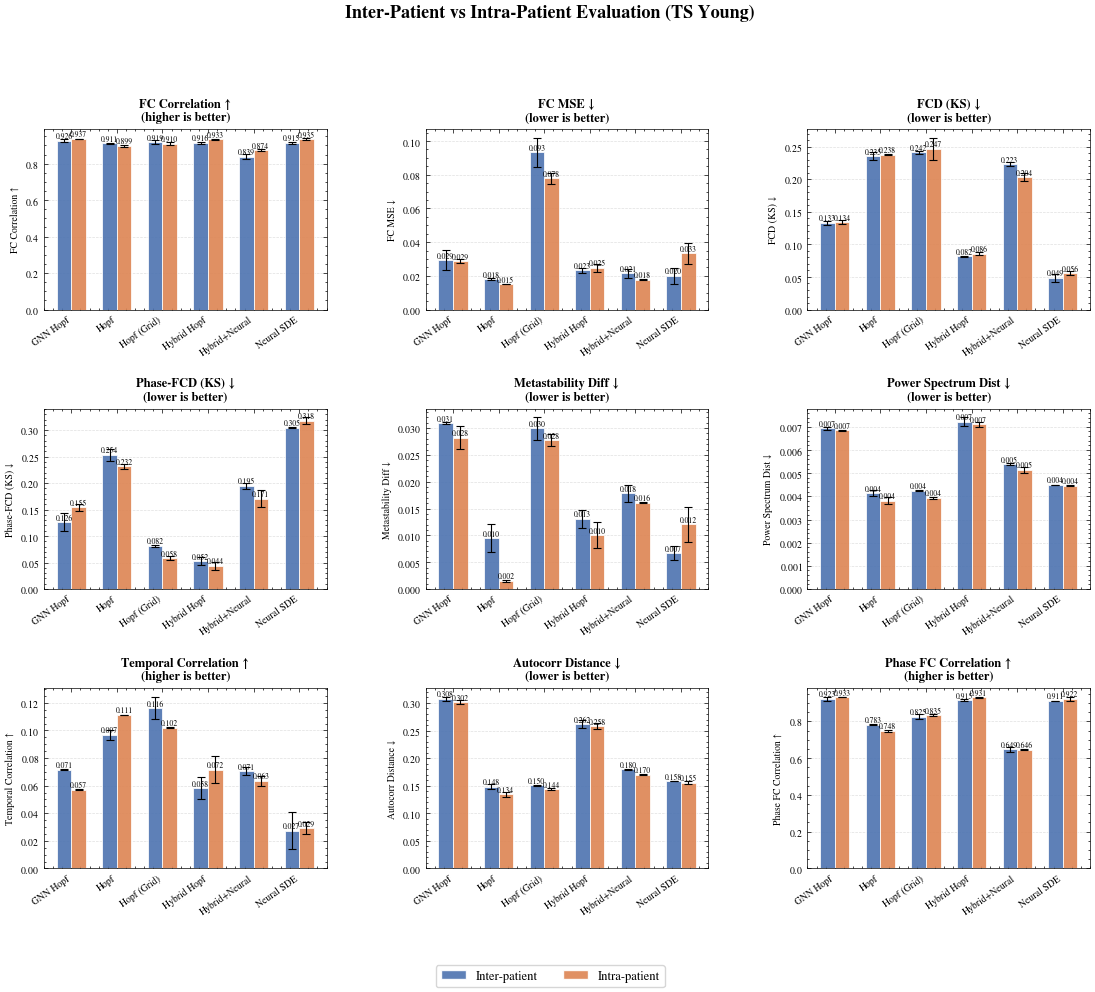

Saved bar plots to paper/images/ts_young


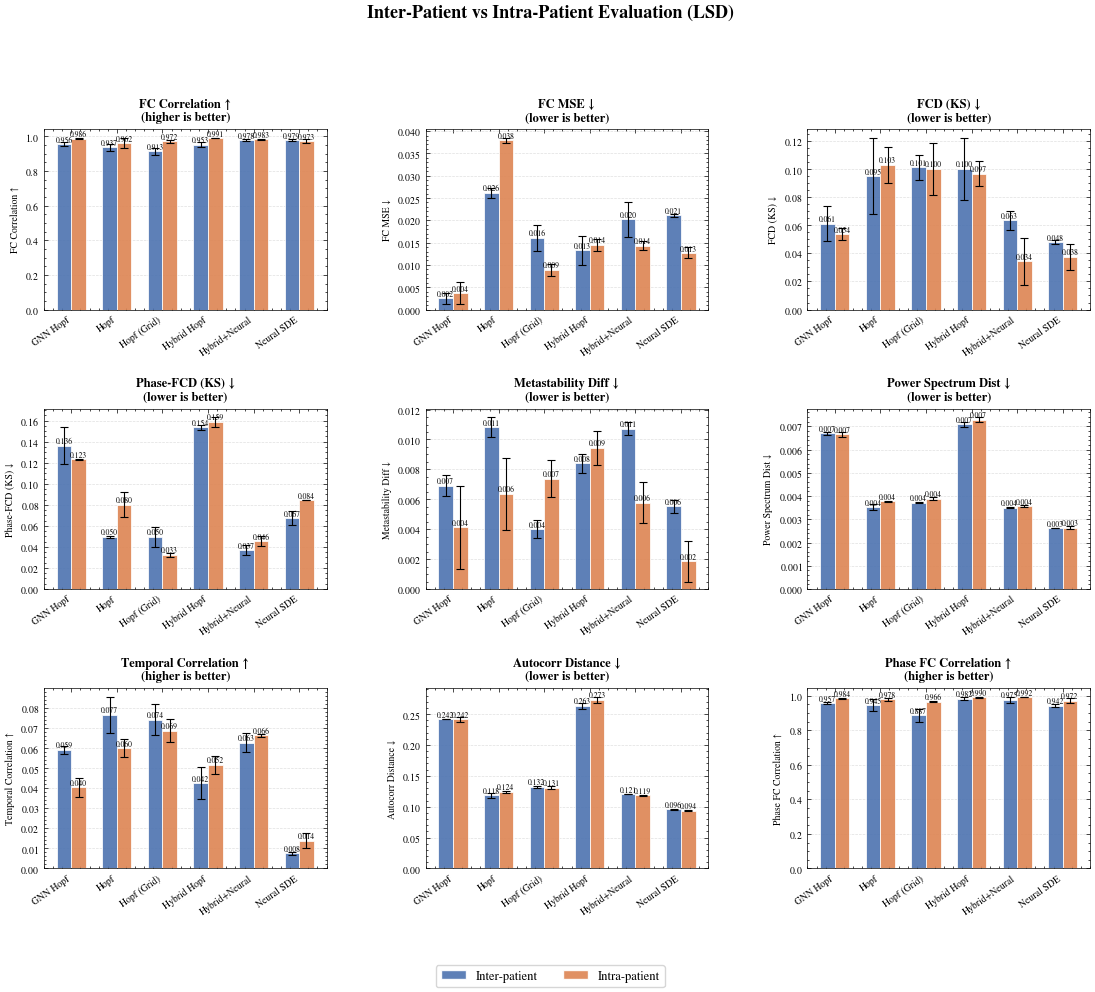

Saved bar plots to paper/images/lsd


In [ ]:
from matplotlib.gridspec import GridSpec
%matplotlib inline

INTER_COLOR = "#4C72B0"
INTRA_COLOR = "#DD8452"

for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    model_names = dataset_results["model_names"]
    inter_results = dataset_results["inter_results"]
    intra_results = dataset_results["intra_results"]

    n_models = len(model_names)
    n_metrics = len(DISPLAY_METRICS)
    n_cols = 3
    n_rows = int(np.ceil(n_metrics / n_cols))
    bar_width = 0.32
    x = np.arange(n_models)

    fig = plt.figure(figsize=(4.5 * n_cols, 3.2 * n_rows))
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.55, wspace=0.35)

    for idx, metric_key in enumerate(DISPLAY_METRICS):
        row, col = divmod(idx, n_cols)
        ax = fig.add_subplot(gs[row, col])

        inter_means = [inter_results[m].get(metric_key, 0) for m in model_names]
        intra_means = [intra_results[m].get(metric_key, 0) for m in model_names]
        inter_stds = [inter_results[m].get(f"{metric_key}_std", 0) for m in model_names]
        intra_stds = [intra_results[m].get(f"{metric_key}_std", 0) for m in model_names]

        bars_inter = ax.bar(
            x - bar_width / 2, inter_means, bar_width,
            yerr=inter_stds, label="Inter-patient",
            color=INTER_COLOR, edgecolor="white", linewidth=0.6,
            capsize=3, error_kw=dict(lw=0.8, capthick=0.8),
            zorder=3, alpha=0.9,
        )
        bars_intra = ax.bar(
            x + bar_width / 2, intra_means, bar_width,
            yerr=intra_stds, label="Intra-patient",
            color=INTRA_COLOR, edgecolor="white", linewidth=0.6,
            capsize=3, error_kw=dict(lw=0.8, capthick=0.8),
            zorder=3, alpha=0.9,
        )

        direction = "higher is better" if metric_key in HIGHER_IS_BETTER else "lower is better"
        pretty_name = METRIC_LABELS.get(metric_key, metric_key)
        ax.set_title(f"{pretty_name}\n({direction})", fontsize=9, fontweight="bold", pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=35, ha="right", fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_ylabel(pretty_name, fontsize=7)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, linewidth=0.5)
        ax.xaxis.grid(False)

        for bars in [bars_inter, bars_intra]:
            for bar in bars:
                h = bar.get_height()
                if not np.isnan(h) and h != 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2, h,
                        f"{h:.3f}", ha="center", va="bottom",
                        fontsize=5.5, fontweight="medium",
                    )

    for idx in range(n_metrics, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        fig.add_subplot(gs[row, col]).set_visible(False)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=INTER_COLOR, edgecolor="white", alpha=0.9),
        plt.Rectangle((0, 0), 1, 1, facecolor=INTRA_COLOR, edgecolor="white", alpha=0.9),
    ]
    fig.legend(
        handles, ["Inter-patient", "Intra-patient"],
        loc="lower center", ncol=2, fontsize=9,
        frameon=True, fancybox=True, shadow=False,
        bbox_to_anchor=(0.5, -0.02),
    )
    fig.suptitle(
        f"Inter-Patient vs Intra-Patient Evaluation ({DATASET_LABELS[dataset_type]})",
        fontsize=13, fontweight="bold", y=1.01,
    )

    out_dir = Path(f"paper/images/{dataset_type}")
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / "intra_vs_inter_barplots.pdf", bbox_inches="tight", dpi=200)
    plt.savefig(out_dir / "intra_vs_inter_barplots.png", bbox_inches="tight", dpi=200)
    plt.show()
    print(f"Saved bar plots to {out_dir}")


## 8. Delta Plot — Intra minus Inter Gap

How much does each model's performance change between the two splits?
Positive delta means the model is *better* on the intra-patient split; negative means it
generalises better to unseen patients. Bars are coloured by sign.

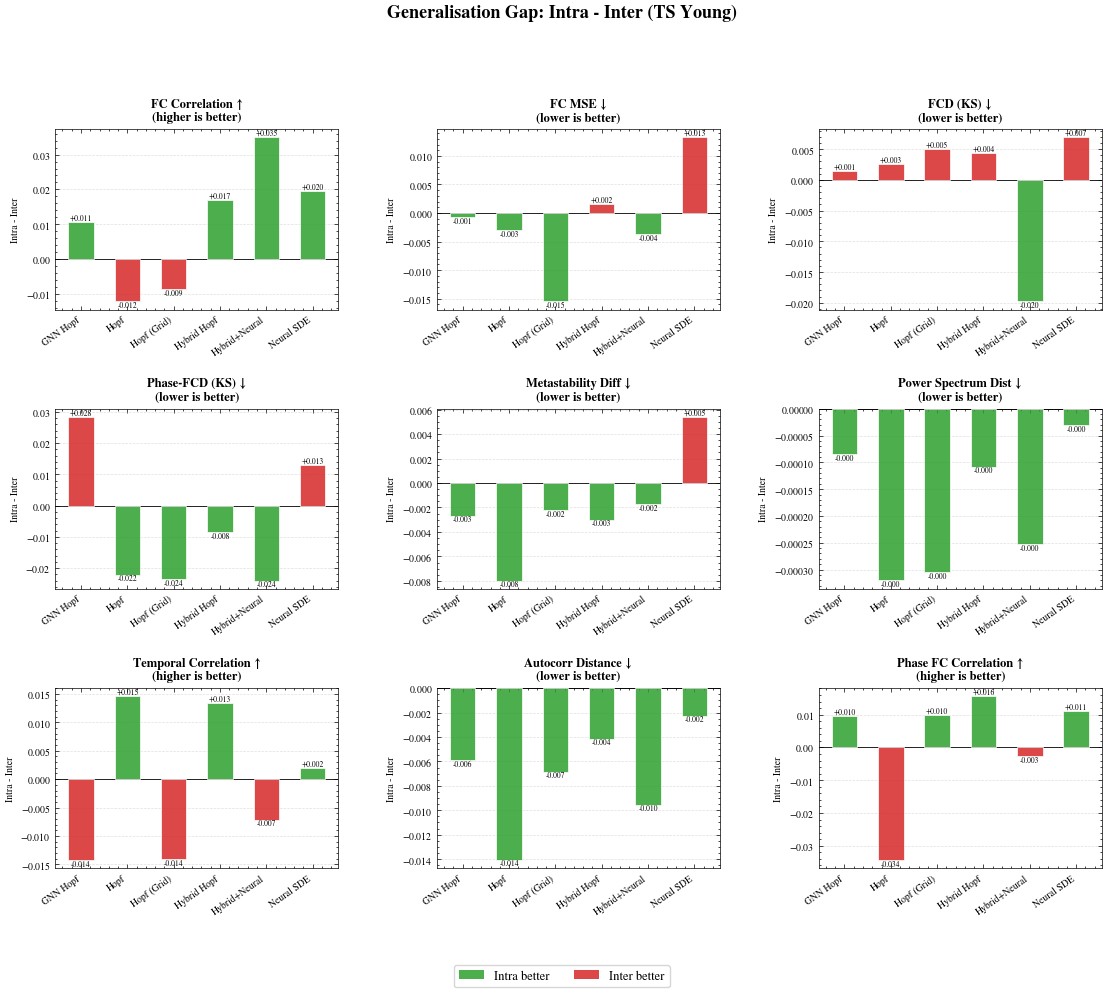

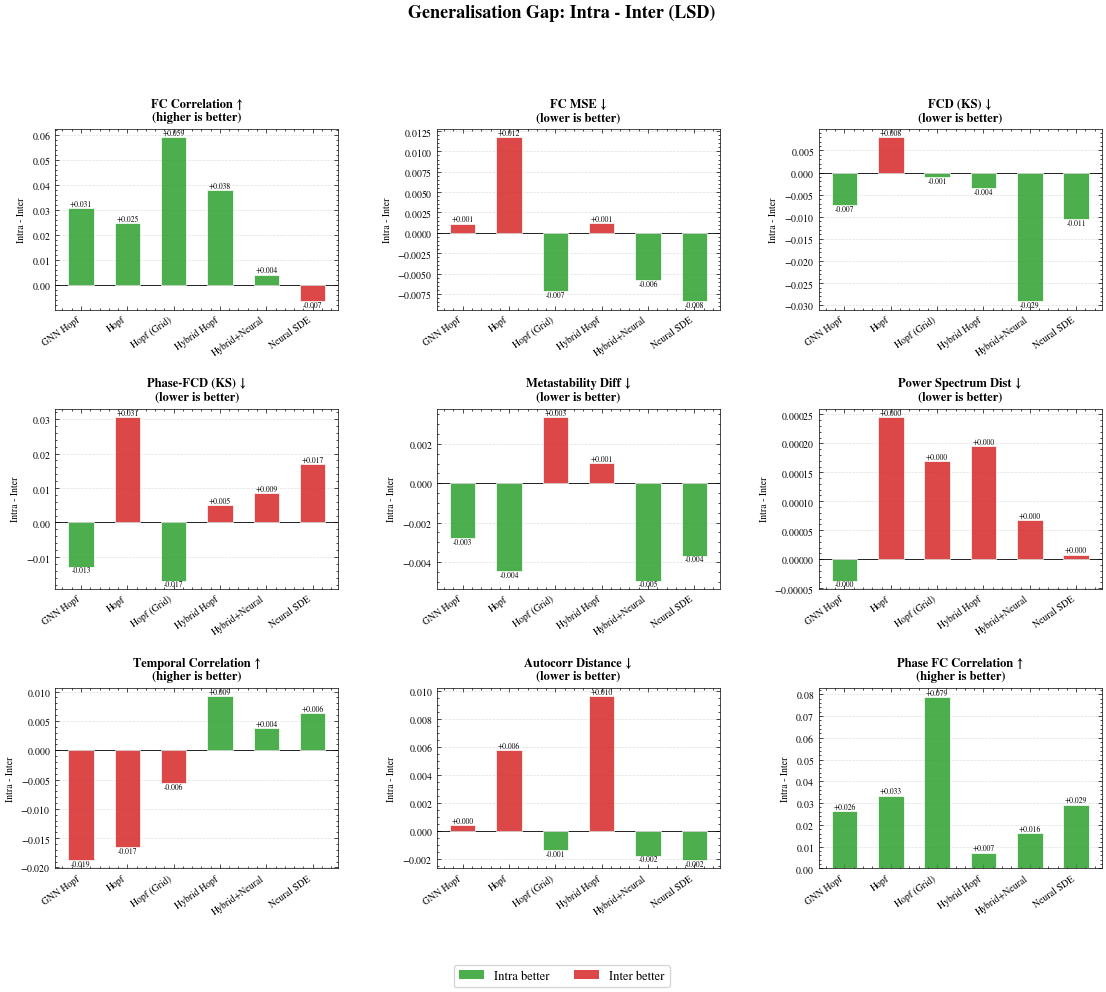

In [ ]:
BETTER_COLOR = "#2ca02c"
WORSE_COLOR = "#d62728"

for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    model_names = dataset_results["model_names"]
    inter_results = dataset_results["inter_results"]
    intra_results = dataset_results["intra_results"]

    n_models = len(model_names)
    n_metrics = len(DISPLAY_METRICS)
    n_cols = 3
    n_rows = int(np.ceil(n_metrics / n_cols))
    x = np.arange(n_models)

    fig = plt.figure(figsize=(4.5 * n_cols, 3.2 * n_rows))
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.55, wspace=0.35)

    for idx, metric_key in enumerate(DISPLAY_METRICS):
        row, col = divmod(idx, n_cols)
        ax = fig.add_subplot(gs[row, col])

        inter_vals = np.array([inter_results[m].get(metric_key, 0) for m in model_names])
        intra_vals = np.array([intra_results[m].get(metric_key, 0) for m in model_names])
        delta = intra_vals - inter_vals

        if metric_key in HIGHER_IS_BETTER:
            colors = [BETTER_COLOR if d > 0 else WORSE_COLOR for d in delta]
        else:
            colors = [BETTER_COLOR if d < 0 else WORSE_COLOR for d in delta]

        ax.bar(x, delta, width=0.55, color=colors, edgecolor="white", linewidth=0.6, zorder=3, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.6, zorder=2)

        pretty_name = METRIC_LABELS.get(metric_key, metric_key)
        direction = "higher is better" if metric_key in HIGHER_IS_BETTER else "lower is better"
        ax.set_title(f"{pretty_name}\n({direction})", fontsize=9, fontweight="bold", pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=35, ha="right", fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_ylabel("Intra - Inter", fontsize=7)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, linewidth=0.5)
        ax.xaxis.grid(False)

        for i, d in enumerate(delta):
            va = "bottom" if d >= 0 else "top"
            ax.text(i, d, f"{d:+.3f}", ha="center", va=va, fontsize=5.5, fontweight="medium")

    for idx in range(n_metrics, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        fig.add_subplot(gs[row, col]).set_visible(False)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=BETTER_COLOR, alpha=0.85),
        plt.Rectangle((0, 0), 1, 1, facecolor=WORSE_COLOR, alpha=0.85),
    ]
    fig.legend(
        handles, ["Intra better", "Inter better"],
        loc="lower center", ncol=2, fontsize=9,
        frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.02),
    )
    fig.suptitle(
        f"Generalisation Gap: Intra - Inter ({DATASET_LABELS[dataset_type]})",
        fontsize=13, fontweight="bold", y=1.01,
    )

    out_dir = Path(f"paper/images/{dataset_type}")
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / "intra_vs_inter_delta.pdf", bbox_inches="tight", dpi=200)
    plt.savefig(out_dir / "intra_vs_inter_delta.png", bbox_inches="tight", dpi=200)
    plt.show()


## 9. Horizontal Grouped Bar — Compact Single-Figure Summary

A condensed horizontal bar chart with all models and metrics in a single figure, ideal for paper appendix or quick comparison.

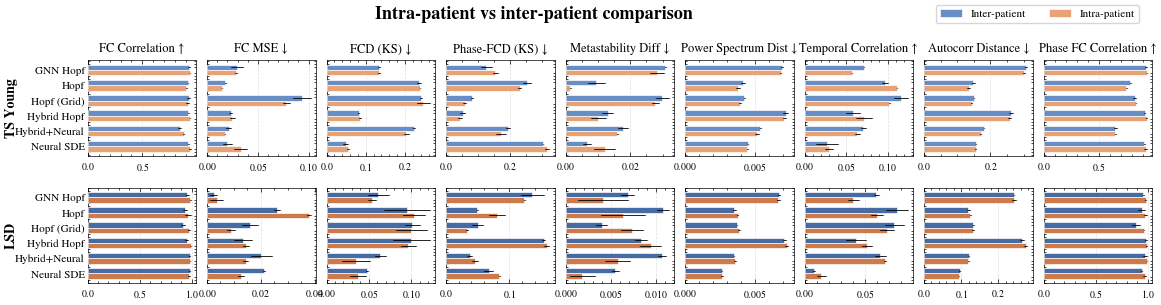

Saved combined comparison plot to paper/images/comparison


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

DATASET_ROW_COLORS = {
    "ts_young": {"inter": "#5B84C4", "intra": "#E59A6B"},
    "lsd": {"inter": "#355F9E", "intra": "#C96F3D"},
}

n_metrics = len(DISPLAY_METRICS)
max_models = max(len(results_by_dataset[dataset_type]["model_names"]) for dataset_type in DATASET_ORDER)
fig, axes = plt.subplots(
    len(DATASET_ORDER), n_metrics,
    figsize=(1.28 * n_metrics + 1.2, 0.28 * max_models * len(DATASET_ORDER)),
    sharey="row",
)

if len(DATASET_ORDER) == 1:
    axes = np.array([axes])
if n_metrics == 1:
    axes = axes[:, np.newaxis]

legend_handles = None

for row, dataset_type in enumerate(DATASET_ORDER):
    dataset_results = results_by_dataset[dataset_type]
    model_names = dataset_results["model_names"]
    inter_results = dataset_results["inter_results"]
    intra_results = dataset_results["intra_results"]
    row_colors = DATASET_ROW_COLORS[dataset_type]
    y = np.arange(len(model_names))
    bar_h = 0.35

    for col, m_key in enumerate(DISPLAY_METRICS):
        ax = axes[row, col]
        inter_vals = [inter_results[name].get(m_key, 0) for name in model_names]
        intra_vals = [intra_results[name].get(m_key, 0) for name in model_names]
        inter_stds = [inter_results[name].get(f"{m_key}_std", 0) for name in model_names]
        intra_stds = [intra_results[name].get(f"{m_key}_std", 0) for name in model_names]

        inter_bars = ax.barh(
            y - bar_h / 2, inter_vals, bar_h, xerr=inter_stds,
            color=row_colors["inter"], alpha=0.92, edgecolor="white", linewidth=0.5,
            capsize=0.1, error_kw=dict(lw=0.6), label="Inter", zorder=3,
        )
        intra_bars = ax.barh(
            y + bar_h / 2, intra_vals, bar_h, xerr=intra_stds,
            color=row_colors["intra"], alpha=0.92, edgecolor="white", linewidth=0.5,
            capsize=0.1, error_kw=dict(lw=0.6), label="Intra", zorder=3,
        )

        if legend_handles is None:
            legend_handles = [inter_bars[0], intra_bars[0]]

        ax.set_yticks(y)
        if col == 0:
            ax.set_yticklabels(model_names, fontsize=8)
            ax.tick_params(axis="y", labelleft=True, length=0, pad=2)
            ax.text(
                -0.7, 0.5, DATASET_LABELS[dataset_type],
                transform=ax.transAxes, rotation=90,
                va="center", ha="center", fontsize=10, fontweight="bold",
            )
        else:
            ax.tick_params(axis="y", labelleft=False, length=0)

        ax.tick_params(axis="x", labelsize=7)
        ax.set_axisbelow(True)
        ax.xaxis.grid(True, linestyle="--", alpha=0.4, linewidth=0.5)
        ax.yaxis.grid(False)
        ax.invert_yaxis()

        if row == 0:
            ax.set_title(METRIC_LABELS.get(m_key, m_key), fontsize=9)

fig.legend(
    legend_handles, ["Inter-patient", "Intra-patient"],
    loc="upper right", ncol=2, fontsize=8,
    frameon=True, bbox_to_anchor=(0.98, 0.94),
)
fig.suptitle(
    "Intra-patient vs inter-patient comparison",
    fontsize=13, fontweight="bold", y=0.92
)

comparison_dir = Path("paper/images/comparison")
comparison_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout(rect=(0.08, 0, 1, 0.95))
plt.subplots_adjust(wspace=0.1)
plt.savefig(comparison_dir / "intra_vs_inter_rotated_both_datasets.pdf", bbox_inches="tight", dpi=200)
# plt.savefig(comparison_dir / "intra_vs_inter_rotated_both_datasets.png", bbox_inches="tight", dpi=200)
plt.show()
print(f"Saved combined comparison plot to {comparison_dir}")

## 8. Save Results to JSON

Persist the per-dataset metrics so they can be reloaded without re-running evaluation.


In [ ]:
import json

for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    output = {
        "dataset_type": dataset_type,
        "test_inter": {
            name: {k: float(v) for k, v in metrics.items()}
            for name, metrics in dataset_results["inter_results"].items()
        },
        "test_intra": {
            name: {k: float(v) for k, v in metrics.items()}
            for name, metrics in dataset_results["intra_results"].items()
        },
    }

    output_path = Path(f"results/{dataset_type}_intra_vs_inter_results.json")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w") as f:
        json.dump(output, f, indent=2, sort_keys=True)

    print(f"Results saved to {output_path}")


Results saved to results/ts_young_intra_vs_inter_results.json
Results saved to results/lsd_intra_vs_inter_results.json
